In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
data0 = pd.read_csv('dataset.csv')
data = data0.copy()
data.head()

,NumHAcceptors,NumHDonors,alkyl_num,frag_sym,HOMO_calc,LUMO_calc,dipole,MPI,surface_min,surface_max,...,anchor_end_PO,anchor_end_SA,anchor_end_SH,anchor_end_SiO,MetalOxide_ITO,MetalOxide_NiOx,MetalOxide_SnO2,MetalOxide_TiO2,MetalOxide_ZnO,PCE
0,2,2,2,1,-5.665071,-1.022318,1.975439,11.42494,-38.62844,53.933991,...,0,0,0,0,0,1,0,0,0,22.40
1,4,2,2,1,-5.146211,-1.007550,1.467697,12.11600,-39.79595,52.674270,...,0,0,0,0,0,1,0,0,0,21.00
2,4,2,4,1,-5.182687,-1.386859,2.954174,12.05384,-40.46879,51.108000,...,0,0,0,0,0,1,0,0,0,25.60
3,3,1,0,0,-8.070575,-1.975575,6.131034,17.92665,-35.95829,45.147690,...,0,1,0,0,0,0,0,1,0,16.54
4,3,1,0,0,-7.655580,-1.919355,3.424702,15.53109,-31.70790,57.597300,...,0,1,0,0,0,0,0,1,0,16.88


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = data.iloc[:,:-1]
y = data.iloc[:,-1] - data['control_PCE']
x = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

from sklearn.model_selection import ShuffleSplit,GridSearchCV, KFold
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

In [3]:
# Xgboost and SHAP
import xgboost as xgb
param_test1 =  {'learning_rate': [0.05],
              'n_estimators': [150],
              'max_depth': [3,5], 
              'min_child_weight': [3,2], 
              'subsample': [0.6],
              'colsample_bytree': [0.4,0.6],
              'gamma': [0.1], 
               'reg_alpha': [0.05,0.1], 
               'reg_lambda': [0.01,0.05,0.1],
   }
other_params={'objective': 'reg:squarederror',
              'seed': 0,
    }
model = xgb.sklearn.XGBRegressor(**other_params)
gsearch=GridSearchCV(model,param_grid=param_test1, scoring='neg_mean_squared_error',cv=10,n_jobs=8,verbose=4)
gsearch.fit(x, y)
xgb_model = gsearch.best_estimator_
print(gsearch.best_score_)
print(gsearch.best_params_)
print(f"RMSE: {np.sqrt(mean_squared_error(y, xgb_model.predict(x)))}")
print(f"r: {stats.pearsonr(y, xgb_model.predict(x))[0]}")


Fitting 10 folds for each of 48 candidates, totalling 480 fits
-1.9753065430720091
{'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 0.05, 'subsample': 0.6}
RMSE: 0.25810109225040356
r: 0.9876955217414525


d:\anaconda3\envs\rdkit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(175, 27)


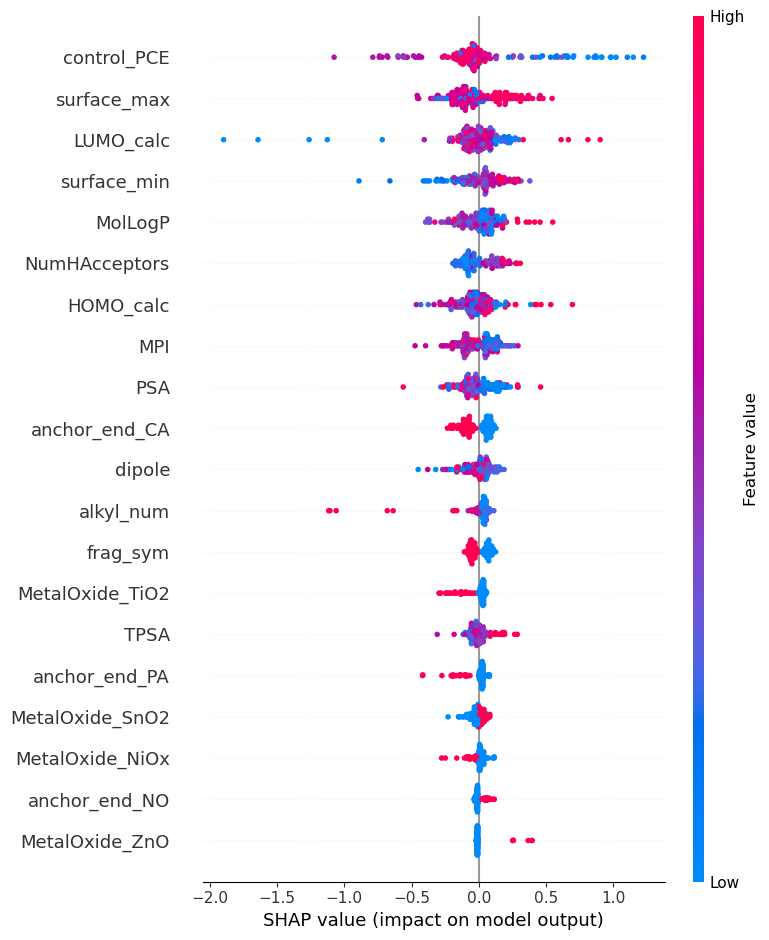

In [ ]:
import shap
rf_exp = shap.TreeExplainer(xgb_model)
shap_xgb = rf_exp.shap_values(x)
print(shap_xgb.shape)

shap.summary_plot(shap_xgb,x,show=False)
plt.rcParams.update({
                'figure.figsize': (10, 12),
                'font.size': 8,
                'axes.titlesize': 8,
                'axes.labelsize':8,
                'lines.linewidth':0.75,
                'font.family': 'Helvetica',
                'pdf.fonttype': 42,
                'ps.fonttype': 42,
                'svg.fonttype': 'none',
                'figure.dpi': 300,
            })
ax = plt.gca()
ax.tick_params()
plt.show()

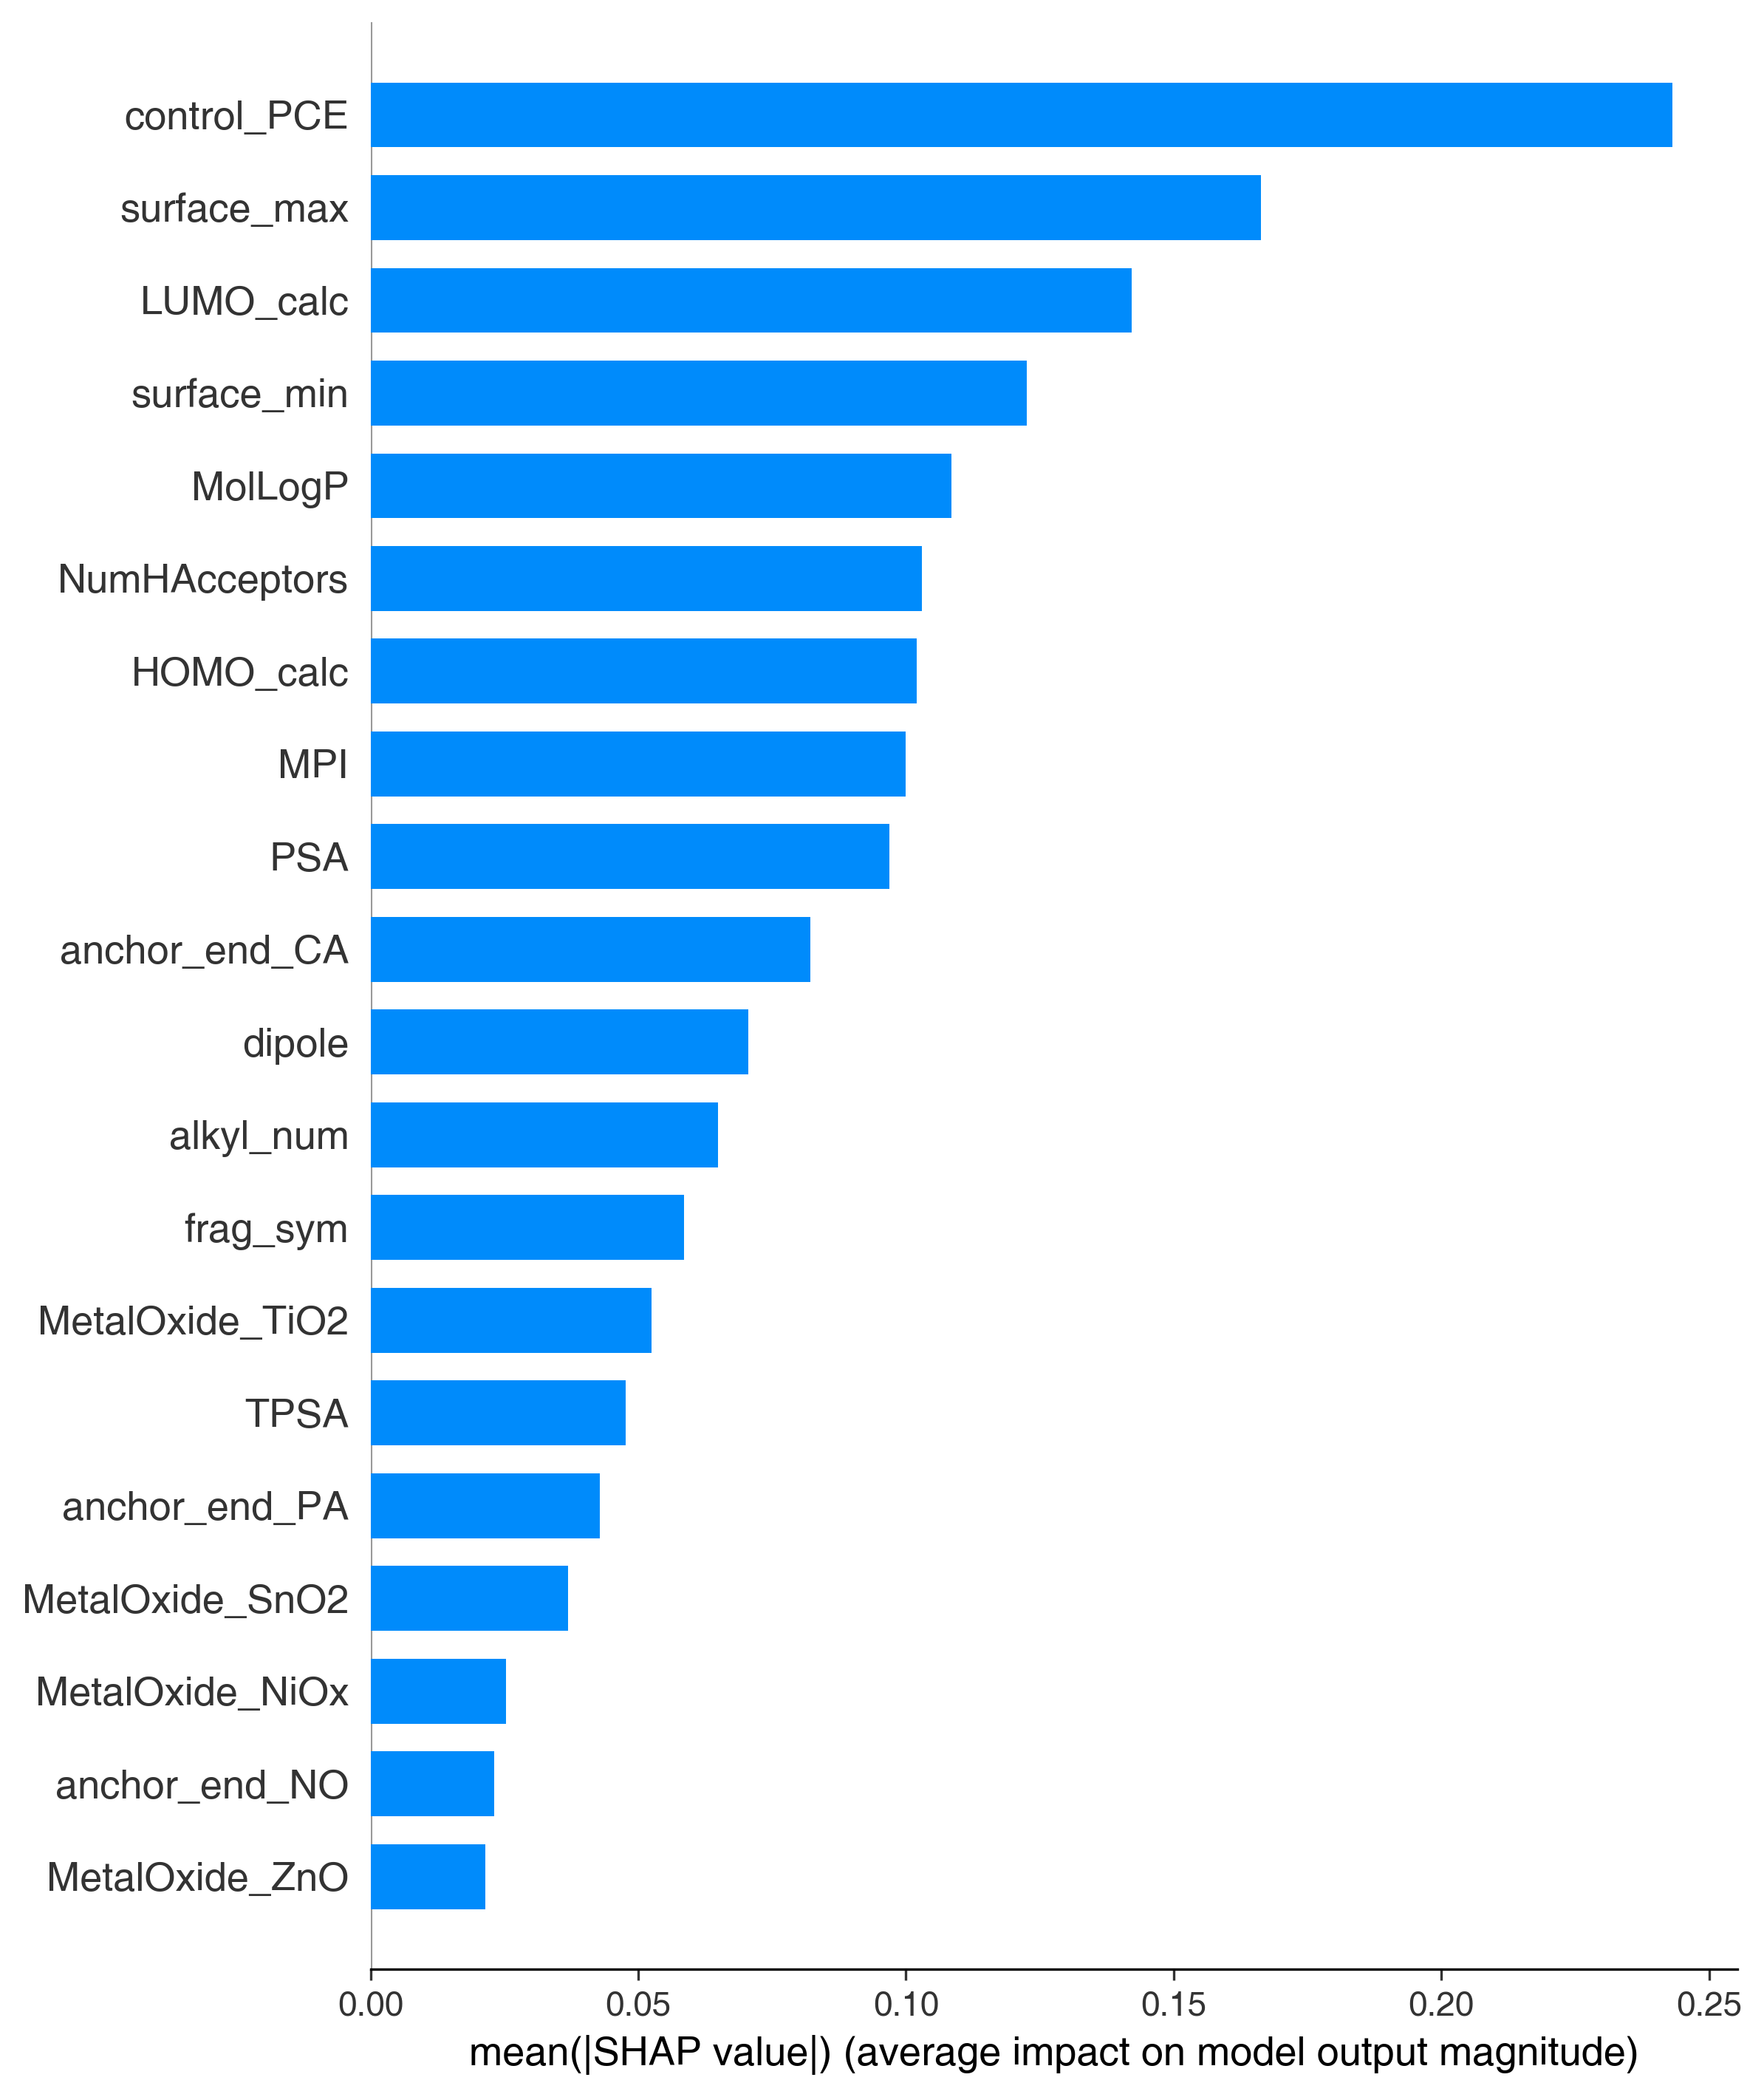

[0.10297059 0.02003627 0.06495837 0.05856315 0.10203863 0.14221907
 0.07052024 0.09997173 0.12251359 0.16628614 0.04762556 0.10846407
 0.09685431 0.24315909 0.         0.08208396 0.02313582 0.04282555
 0.00151086 0.0015797  0.00074818 0.001186   0.00143085 0.02531052
 0.03685112 0.05244339 0.0214632 ]


In [ ]:
shap.summary_plot(shap_xgb, x, plot_type="bar",show=False)
plt.show()
abs_shapvalue = abs(shap_xgb)
shap_average = np.average(abs_shapvalue,axis=0)
print(shap_average)